In [13]:
import os
import sys

sys.path.append(os.path.abspath("../"))

from src.evaluation import *
from src.visualization import plot_metric_surface

import warnings

warnings.filterwarnings("ignore")

In [4]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

x_test = pd.read_csv(r"../data/x_test.txt", sep=" ")

In [5]:
all_features = list(x_train.columns)
print(all_features)

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V115', 'V116', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V123', 'V124', 'V125', 'V126', 'V127', 'V128', 'V129', 'V130', 'V131', 'V132', 'V133', 'V134', 'V135', 'V136', 'V137', 'V138', 'V1

In [5]:
results_all = evaluate_features_XGBClassifier(
    all_features,
    x_train,
    y_train
)

for k, v in results_all.items():

    if k not in ["oof_probs", "confusion_matrix"]:
        print(k, ":", v)

print("\nConfusion matrix")
print(results_all["confusion_matrix"])

n_features : 500
auc : 0.7307769971020133
accuracy : 0.6842
precision : 0.6861941827120033
recall : 0.6732315112540193
f1 : 0.6796510448366808
profit : 6610
score : -93390
top_n : 1000

Confusion matrix
[[1746  766]
 [ 813 1675]]


In [6]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(x_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [7]:
importance = pd.Series(
    model.feature_importances_,
    index=x_train.columns
)

importance = importance.sort_values(
    ascending=False
)

print(importance.head(20))

V11     0.005317
V416    0.005171
V255    0.005153
V160    0.005146
V176    0.005025
V191    0.004417
V342    0.004129
V380    0.003960
V224    0.003927
V215    0.003798
V265    0.003713
V117    0.003675
V345    0.003667
V329    0.003482
V390    0.003449
V483    0.003343
V227    0.003247
V46     0.003240
V161    0.003165
V168    0.003055
dtype: float32


In [16]:
feature_counts = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 30, 50, 75, 100]
summary = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for n in feature_counts:

    features = importance.head(n).index.tolist()

    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

    fold_results = []

    for train_idx, val_idx in cv.split(x_train, y_train):
        X_tr = x_train.iloc[train_idx][features]
        y_tr = y_train.iloc[train_idx]

        X_val = x_train.iloc[val_idx][features]
        y_val = y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)

        scores = get_prediction_scores(model, X_val)

        preds = (scores > 0.5).astype(int)

        metrics = evaluate_model(
            y_val,
            preds,
            n_features=n,
            model_name="XGBClassifier"
        )

        fold_results.append(metrics)

    df = pd.DataFrame(fold_results)

    summary_row = df.mean(numeric_only=True).to_dict()

    summary_row["accuracy_std"] = df["accuracy"].std()
    summary_row["precision_std"] = df["precision"].std()
    summary_row["recall_std"] = df["recall"].std()
    summary_row["f1_std"] = df["f1"].std()
    summary_row["profit_std"] = df["profit"].std()
    summary_row["score_std"] = df["score"].std()

    summary_row["n_features"] = n
    summary_row["model"] = "XGBClassifier"

    summary.append(summary_row)

    print(
        f"Top {n:3d}"
        f" | Profit={summary_row['profit']:.0f}"
        f" | Score={summary_row['score']:.0f}"
    )

Top   4 | Profit=1725 | Score=925
Top   5 | Profit=1907 | Score=907
Top   6 | Profit=2064 | Score=864
Top   7 | Profit=2149 | Score=749
Top   8 | Profit=2309 | Score=709
Top   9 | Profit=2358 | Score=558
Top  10 | Profit=2459 | Score=459
Top  11 | Profit=2412 | Score=212
Top  12 | Profit=2536 | Score=136
Top  13 | Profit=2509 | Score=-91
Top  14 | Profit=2580 | Score=-220
Top  15 | Profit=2681 | Score=-319
Top  16 | Profit=2679 | Score=-521
Top  17 | Profit=2738 | Score=-662
Top  18 | Profit=2739 | Score=-861
Top  19 | Profit=2717 | Score=-1083
Top  20 | Profit=2706 | Score=-1294
Top  30 | Profit=2752 | Score=-3248
Top  50 | Profit=2739 | Score=-7261
Top  75 | Profit=2700 | Score=-12300
Top 100 | Profit=2771 | Score=-17229


In [18]:
summary = pd.DataFrame(
    summary,
    columns=[
        "n_features",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "profit",
        "score"
    ]
)

summary.sort_values(
    "score",
    ascending=False,
    inplace=True
)

print(summary)

    n_features  accuracy  precision    recall        f1  profit    score
0            4    0.5956   0.613904  0.506031  0.554569  1725.0    925.0
1            5    0.6122   0.626730  0.545820  0.583389  1907.0    907.0
2            6    0.6310   0.646338  0.571142  0.606357  2064.0    864.0
3            7    0.6418   0.657938  0.583601  0.618531  2149.0    749.0
4            8    0.6586   0.671631  0.614141  0.641554  2309.0    709.0
5            9    0.6642   0.676854  0.622573  0.648462  2358.0    558.0
6           10    0.6756   0.687017  0.640257  0.662636  2459.0    459.0
7           11    0.6698   0.681200  0.633026  0.656098  2412.0    212.0
8           12    0.6850   0.695837  0.652315  0.673219  2536.0    136.0
9           13    0.6828   0.695200  0.645885  0.669490  2509.0    -91.0
10          14    0.6898   0.699681  0.660352  0.679372  2580.0   -220.0
11          15    0.7002   0.706869  0.680055  0.693025  2681.0   -319.0
12          16    0.7020   0.711173  0.675627  0.69

In [20]:
best_n = summary.iloc[0]["n_features"]
print("BEST =", best_n)

BEST = 4.0


In [21]:
best_features = (
    importance
    .head(int(best_n))
    .index
    .tolist()
)

final_model_MM = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

final_model_MM.fit(
    x_train[best_features],
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [22]:
test_probs = final_model_MM.predict_proba(
    x_test[best_features]
)[:, 1]

In [ ]:
top_n_customers = 1000

test_preds = top_n_predictions(test_probs, top_n_customers)

selected_clients = np.where(test_preds == 1)[0]

print("Client number on test set:", len(selected_clients))

Client number on test set: 1000


In [26]:
submission = pd.DataFrame({
    "customer_id": selected_clients
})

print(submission.head())
print("Total submission rows:", len(submission))

   customer_id
0            1
1            4
2           13
3           19
4           22
Total submission rows: 1000


### XGBoost model in similar setup as other models

In [10]:
from sklearn.preprocessing import MinMaxScaler

feature_importance_df = pd.read_csv("../outputs/feature_importance_ranking_xgb.csv")
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [11]:
MODEL_CONFIGS = {
    "xgboost": XGBClassifier
}

PARAM_GRID = {
    "xgboost": {
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.05, 0.1],
        "n_estimators": [100, 300],
    }
}

K_VALUES = range(1, 21)

TOP_N_VALUES = [50, 100, 250, 500, 750, 900, 950, 1000]
all_results = []

sorted_features = feature_importance_df.sort_values("xgb_rank")["feature"].values
print(f"First feature is: {sorted_features[0]}")

for model_name, model_class in MODEL_CONFIGS.items():

    print(f"\nRunning model: {model_name}")

    grid = PARAM_GRID[model_name]

    for max_depth in grid["max_depth"]:
        for learning_rate in grid["learning_rate"]:
            for n_estimators in grid["n_estimators"]:

                print(
                    f"depth={max_depth}, "
                    f"lr={learning_rate}, "
                    f"trees={n_estimators}, "
                )

                for k in K_VALUES:

                    selected_features = sorted_features[:k]
                    X_sel = x_train_scaled[selected_features]

                    model = model_class(
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        n_estimators=n_estimators,
                        colsample_bytree=0.8,
                        eval_metric="logloss",
                        random_state=42
                    )

                    for t in TOP_N_VALUES:
                        summary = cross_val_eval(
                            model=model,
                            X=X_sel,
                            y=y_train,
                            n_features=k,
                            model_name=(
                                f"{model_name}_"
                                f"d{max_depth}_"
                                f"lr{learning_rate}_"
                                f"n{n_estimators}_"
                                f"k{k}"
                            ),
                            top_n=t, scaled_features=True
                        )

                        summary["model_type"] = model_name
                        summary["max_depth"] = max_depth
                        summary["learning_rate"] = learning_rate
                        summary["n_estimators"] = n_estimators
                        summary["k"] = k
                        summary["top_n"] = t

                        all_results.append(summary)

final_results = pd.DataFrame(all_results)

First feature is: V224

Running model: xgboost
depth=3, lr=0.03, trees=100, 
depth=3, lr=0.03, trees=300, 
depth=3, lr=0.05, trees=100, 
depth=3, lr=0.05, trees=300, 
depth=3, lr=0.1, trees=100, 
depth=3, lr=0.1, trees=300, 
depth=5, lr=0.03, trees=100, 
depth=5, lr=0.03, trees=300, 
depth=5, lr=0.05, trees=100, 
depth=5, lr=0.05, trees=300, 
depth=5, lr=0.1, trees=100, 
depth=5, lr=0.1, trees=300, 
depth=7, lr=0.03, trees=100, 
depth=7, lr=0.03, trees=300, 
depth=7, lr=0.05, trees=100, 
depth=7, lr=0.05, trees=300, 
depth=7, lr=0.1, trees=100, 
depth=7, lr=0.1, trees=300, 


In [12]:
final_results.sort_values(by="score", ascending=False).head(20)

,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,...,profit_std,score_std,model,threshold,top_n,model_type,max_depth,learning_rate,n_estimators,k
367,0.6012,0.747,0.300241,0.428325,1241.0,1001.0,6,0.008044,0.020187,0.008084,...,60.559888,60.559888,xgboost_d3_lr0.05_n100_k6,None,1000,xgboost,3,0.05,100,6
47,0.6008,0.746,0.299836,0.427749,1238.0,998.0,6,0.005541,0.014748,0.005706,...,44.243644,44.243644,xgboost_d3_lr0.03_n100_k6,None,1000,xgboost,3,0.03,100,6
527,0.5980,0.739,0.297026,0.423738,1217.0,977.0,6,0.003536,0.008944,0.003559,...,26.832816,26.832816,xgboost_d3_lr0.05_n300_k6,None,1000,xgboost,3,0.05,300,6
351,0.5868,0.711,0.285771,0.407683,1133.0,973.0,4,0.011032,0.027704,0.011095,...,83.111371,83.111371,xgboost_d3_lr0.05_n100_k4,None,1000,xgboost,3,0.05,100,4
207,0.5964,0.735,0.295417,0.421444,1205.0,965.0,6,0.006189,0.015811,0.006265,...,47.434165,47.434165,xgboost_d3_lr0.03_n300_k6,None,1000,xgboost,3,0.03,300,6
359,0.5908,0.721,0.289788,0.413414,1163.0,963.0,5,0.008643,0.022192,0.008775,...,66.577023,66.577023,xgboost_d3_lr0.05_n100_k5,None,1000,xgboost,3,0.05,100,5
199,0.5904,0.720,0.289384,0.412838,1160.0,960.0,5,0.010164,0.026220,0.010344,...,78.660664,78.660664,xgboost_d3_lr0.03_n300_k5,None,1000,xgboost,3,0.03,300,5
511,0.5848,0.706,0.283765,0.404820,1118.0,958.0,4,0.009524,0.023292,0.009471,...,69.874888,69.874888,xgboost_d3_lr0.05_n300_k4,None,1000,xgboost,3,0.05,300,4
687,0.5952,0.732,0.294210,0.419723,1196.0,956.0,6,0.008526,0.021679,0.008622,...,65.038450,65.038450,xgboost_d3_lr0.1_n100_k6,None,1000,xgboost,3,0.10,100,6
671,0.5844,0.705,0.283360,0.404243,1115.0,955.0,4,0.008620,0.021506,0.008643,...,64.517440,64.517440,xgboost_d3_lr0.1_n100_k4,None,1000,xgboost,3,0.10,100,4


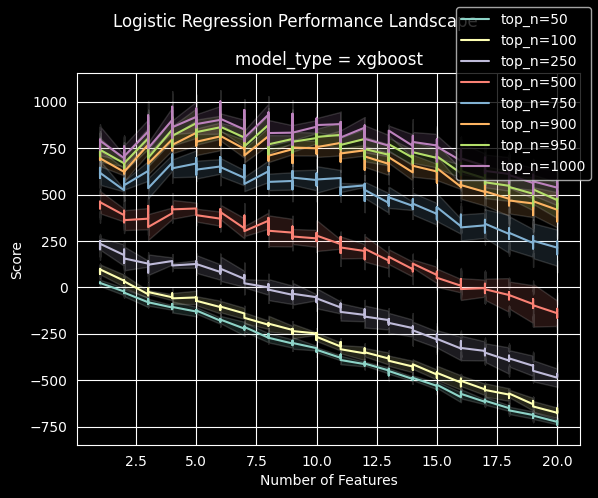

In [14]:
plot_metric_surface(
    df=final_results,
    x_col="n_features",
    y_col="score",
    split_col="model_type",
    line_col="top_n",
    std_col="score_std",
    title="Logistic Regression Performance Landscape",
    x_label="Number of Features",
    y_label="Score"
)

#### XGBoost - using MI + XGBoost feature importance

In [5]:
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

xgb_for_ranking = XGBClassifier(
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    eval_metric="logloss",
    random_state=42
)

xgb_for_ranking.fit(x_train_scaled, y_train)

xgb_importance = pd.Series(
    xgb_for_ranking.feature_importances_,
    index=x_train_scaled.columns
)

xgb_features = (
    xgb_importance
    .sort_values(ascending=False)
    .index
    .tolist()
)


MODEL_CONFIGS = {
    "xgboost": XGBClassifier
}

PARAM_GRID = {
    "xgboost": {
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.05, 0.1],
        "n_estimators": [100, 300],
    }
}


K_VALUES = range(1, 31)
TOP_N_VALUES = [50, 100, 250, 500, 750, 900, 950, 1000]


all_results = []



for model_name, model_class in MODEL_CONFIGS.items():

    grid = PARAM_GRID[model_name]

    for max_depth in grid["max_depth"]:
        for learning_rate in grid["learning_rate"]:
            for n_estimators in grid["n_estimators"]:

                print(
                    f"{model_name} | "
                    f"d={max_depth} "
                    f"lr={learning_rate} "
                    f"n={n_estimators}"
                )

                for k in K_VALUES:

                    selected_features = xgb_features[:k]

                    X_sel = x_train_scaled[selected_features]

                    model = model_class(
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        n_estimators=n_estimators,
                        colsample_bytree=0.8,
                        eval_metric="logloss",
                        random_state=42
                    )

                    for t in TOP_N_VALUES:
                        summary = cross_val_eval(
                            model=model,
                            X=X_sel,
                            y=y_train,
                            n_features=k,
                            model_name=(
                                f"{model_name}_"
                                f"d{max_depth}_"
                                f"lr{learning_rate}_"
                                f"n{n_estimators}_"
                                f"k{k}"
                            ),
                            top_n=t, scaled_features=True
                        )

                        summary["model_type"] = model_name
                        summary["max_depth"] = max_depth
                        summary["learning_rate"] = learning_rate
                        summary["n_estimators"] = n_estimators
                        summary["k"] = k
                        summary["top_n"] = t

                        all_results.append(summary)


final_results_xg = pd.DataFrame(all_results)

xgboost | d=3 lr=0.03 n=100
xgboost | d=3 lr=0.03 n=300
xgboost | d=3 lr=0.05 n=100
xgboost | d=3 lr=0.05 n=300
xgboost | d=3 lr=0.1 n=100
xgboost | d=3 lr=0.1 n=300
xgboost | d=5 lr=0.03 n=100
xgboost | d=5 lr=0.03 n=300
xgboost | d=5 lr=0.05 n=100
xgboost | d=5 lr=0.05 n=300
xgboost | d=5 lr=0.1 n=100
xgboost | d=5 lr=0.1 n=300
xgboost | d=7 lr=0.03 n=100
xgboost | d=7 lr=0.03 n=300
xgboost | d=7 lr=0.05 n=100
xgboost | d=7 lr=0.05 n=300
xgboost | d=7 lr=0.1 n=100
xgboost | d=7 lr=0.1 n=300


In [6]:
final_results_xg.sort_values(by="score", ascending=False).head(20)

,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,...,profit_std,score_std,model,threshold,top_n,model_type,max_depth,learning_rate,n_estimators,k
35,0.6056,0.758,0.304663,0.434633,1274.0,1034.0,6,0.008325,0.020797,0.008353,...,62.389903,62.389903,xgboost_d3_lr0.03_n300_k6,None,1000,xgboost,3,0.03,300,6
5,0.6040,0.754,0.303050,0.432335,1262.0,1022.0,6,0.011467,0.029240,0.011604,...,87.721149,87.721149,xgboost_d3_lr0.03_n100_k6,None,1000,xgboost,3,0.03,100,6
125,0.6032,0.752,0.302249,0.431191,1256.0,1016.0,6,0.009628,0.024393,0.009715,...,73.177866,73.177866,xgboost_d3_lr0.1_n100_k6,None,1000,xgboost,3,0.10,100,6
95,0.6028,0.751,0.301848,0.430618,1253.0,1013.0,6,0.009039,0.022749,0.009096,...,68.245879,68.245879,xgboost_d3_lr0.05_n300_k6,None,1000,xgboost,3,0.05,300,6
65,0.6024,0.750,0.301446,0.430045,1250.0,1010.0,6,0.008081,0.020310,0.008129,...,60.930288,60.930288,xgboost_d3_lr0.05_n100_k6,None,1000,xgboost,3,0.05,100,6
36,0.6060,0.759,0.305064,0.435206,1277.0,997.0,7,0.009513,0.023822,0.009555,...,71.466775,71.466775,xgboost_d3_lr0.03_n300_k7,None,1000,xgboost,3,0.03,300,7
305,0.6000,0.744,0.299030,0.426600,1232.0,992.0,6,0.010794,0.027704,0.010954,...,83.111371,83.111371,xgboost_d5_lr0.1_n100_k6,None,1000,xgboost,5,0.10,100,6
126,0.6052,0.757,0.304261,0.434060,1271.0,991.0,7,0.009039,0.022528,0.009063,...,67.583282,67.583282,xgboost_d3_lr0.1_n100_k7,None,1000,xgboost,3,0.10,100,7
186,0.6052,0.757,0.304259,0.434058,1271.0,991.0,7,0.012637,0.031741,0.012709,...,95.223421,95.223421,xgboost_d5_lr0.03_n100_k7,None,1000,xgboost,5,0.03,100,7
6,0.6048,0.756,0.303853,0.433480,1268.0,988.0,7,0.013103,0.033429,0.013263,...,100.287088,100.287088,xgboost_d3_lr0.03_n100_k7,None,1000,xgboost,3,0.03,100,7


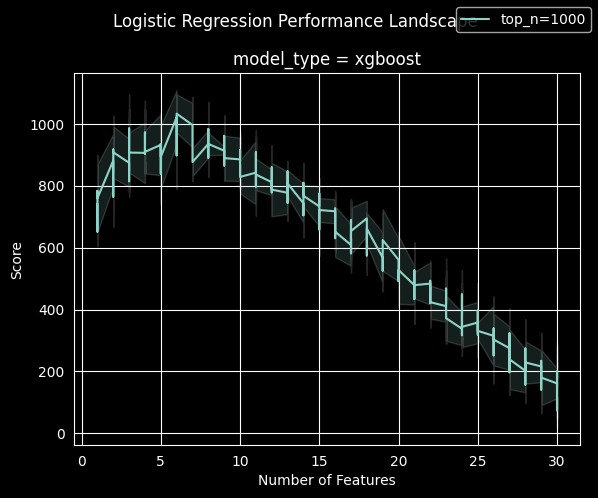

In [15]:
plot_metric_surface(
    df=final_results_xg,
    x_col="n_features",
    y_col="score",
    split_col="model_type",
    line_col="top_n",
    std_col="score_std",
    title="Logistic Regression Performance Landscape",
    x_label="Number of Features",
    y_label="Score"
)